----------------- buld mini clawdbot from scratch -----------------

referenece:
github:  https://youtu.be/sfi_xebGsSw?si=Z4YHTVV8SBiI3gYr

https://github.com/VizuaraAILabs/Slack-ClawdBot/

elevan labs : where i can convert text to my voice 

raj.dandekar8@gmail.com

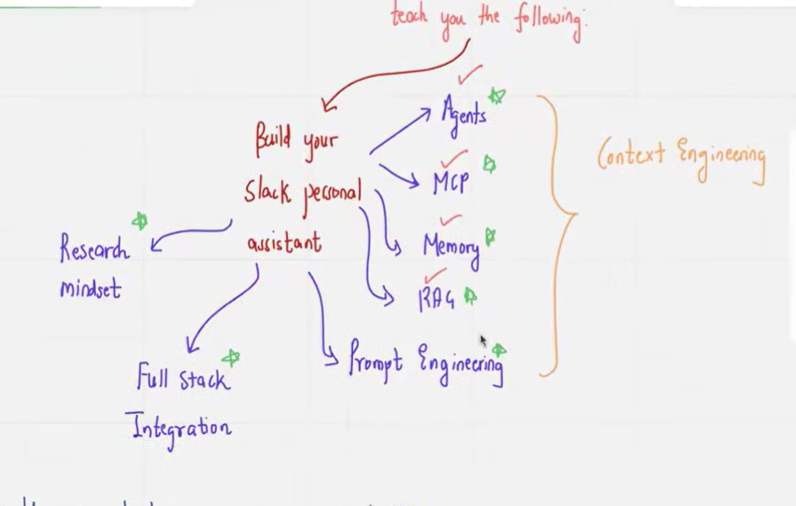

it uses the complex memory system

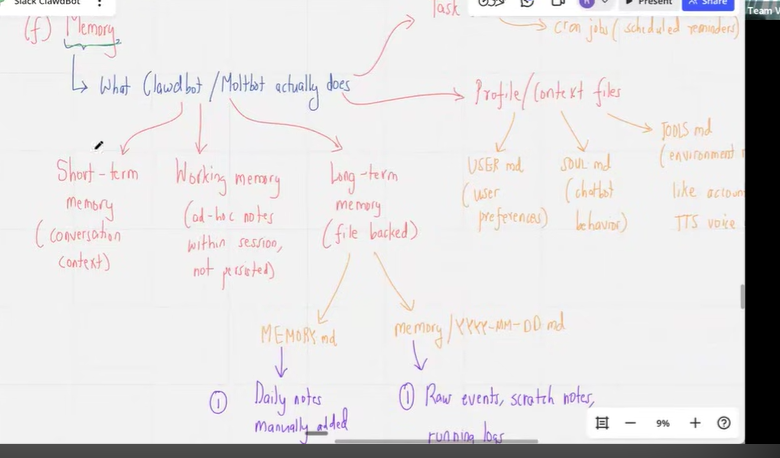

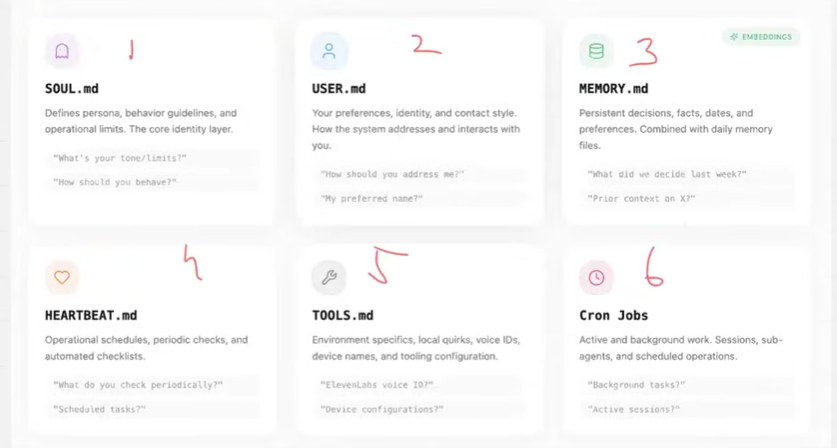

crone job: 

foundation prinicipal block

6 fundamental principal or concept  for this project 
1. llm
2. rag
3. agent
4. tools
5. mcp
6. memory

total we called it has context engineering

n8n is used for assemble component .


------------------- fundamental of principal -------------

1. large language model 

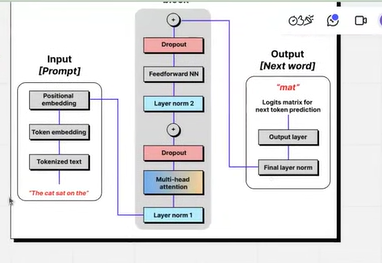

it has two stages 1. pretraining and 2. fine tuning

process:

www --> llm ----> it will understand the input

difference b/w context lenght and context vector??
context lenght means it can process the certain amount information.




2. RAG-retrival augumented generation

user  question converted into embedding and then apply cosine similarity search with data and send all this information to llm.


there are  two indexing:
1. background indexing
2. live indexing

background indexing - after every one hour you can make index the information and make a embedding vector ready , so it will reduce the time.

chunking used is fixed sized chunking
vector database : chromadb


note :more indexing == accuracy is better
Q/a - how storing happen for background indexing ??




3. agent and tools

what if not retrive i want to perform something so thats why these agent comes into picture. but 1st 2 principal was fail for to perform these operation 






react came to picture not only listen and it can act . i think it is the dom concept 

chain of though prompting:


agent work as TAO loop - though action observation:


how to tool works??
take an example of weather

1. what is the weather in paris?? it uses api
2. llm  - it recoginise tha weather tool can be used
3. generate text that represents tool call - call weather tool
4. agent reads this response 
5. agent executes on LLMs benchmarks
6. agents get weather data
7. LLM uses this weather data for further response



thought action observation loop:


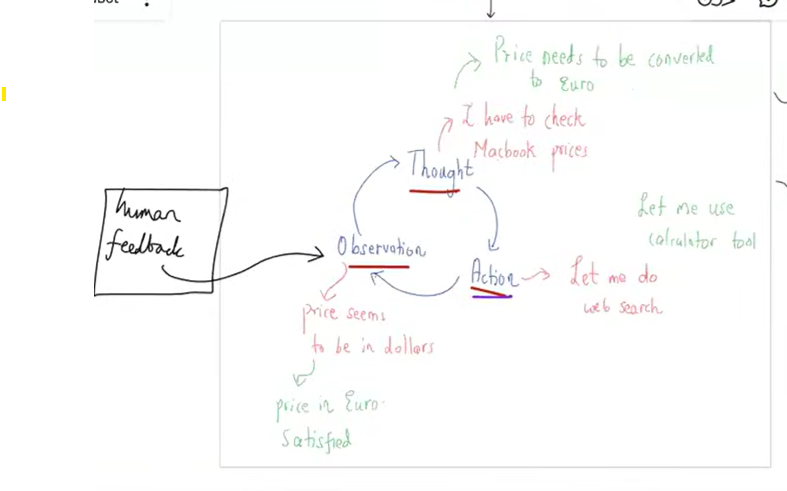

input- llm understand- select the tool - observe the ouput - if no  like this loop happen

production level discusion:

tool calling interface-
it is like function.

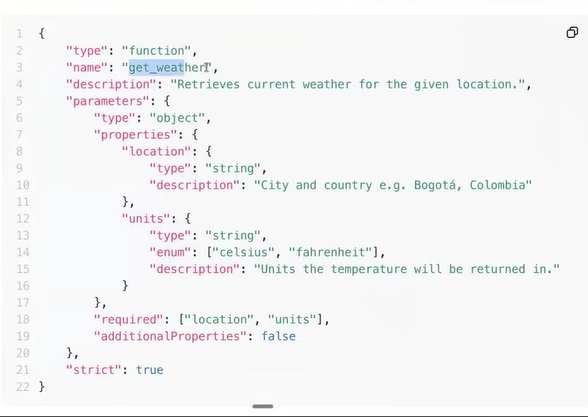






if you use perfectly description it can reduces the hallucination


reference: https://developers.openai.com/api/docs/guides/function-calling

principle of least astonishment- you need to follow in tool colling. it tells that make a as simple





mcp -model context protocol

for now almost all using mcp othervice you need to write tool function


benifit of mcp:


In [3]:
!pip install snthropic openai -q
print("installation completed")

installation completed


ERROR: Could not find a version that satisfies the requirement snthropic (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for snthropic


In [2]:
import json
import re
from dataclasses import dataclass,field
from typing import Callable,Optional,List,Dict,Any
from getpass import getpass
from IPython.display import display,HTML
print("Imports complete")

Imports complete


4. Building the agent

we will build the agent in  four parts:  
1. data strutre ,
2. tools 
3. the agent class and 
4. visualisarion


4.1 Data Structures

these classes represent the components of our agent

In [4]:
from dataclasses import dataclass, field
from typing import Callable,Optional,List,Dict
@dataclass  # it is utility , it can eliminates the need to write boilerplate method like __int__(),__repr__(),__eq__()
class Tool: 
    """represrnt a tool the agent can use"""
    name:str
    description:str
    func:callable
    
@dataclass 
class TAOStep:
    """a single though action observation step"""
    thought:str
    action:Optional[str]=None
    observation:Optional[str]=None
    action_input:Optional[str]=None
    final_answer:Optional[str]=None
    
    
@dataclass
class ExecutionTrace:
    """a complete record of an agent execution"""
    query:str
    steps:List[TAOStep]=field(default_factory=list)
    
print("Data structure defined")

Data structure defined


4.2 tools 

tools ate functions the agent acan call, in aproduction system these would connect to real apis, here we use simulated responses for demonstration.

In [5]:
def get_weather(city:str)->str:
    """ get current weather for a city"""
    
    weather_data={
        "san francisco": (65, "Partly cloudy", 72),
        "new york": (75, "Sunny", 80),
        "london": (60, "Rainy", 65),
        "paris": (70, "Cloudy", 75),
        "tokyo": (80, "Sunny", 85),
        "sydney": (68, "Partly cloudy", 78),
        " berlin": (62, "Rainy", 68)
    }
    
    temp,condition,humidity=weather_data.get(city.lower(),(70,"clear",50))
    celsius=(temp-32)*5/9
    
    return f" weather in {city}:{temp} F, {celsius:.1f}C, {condition}, humidity: {humidity}%"

def calculate(expression:str)->str:
    """ evaluate a math expression"""
    allowed_chars=set("0123456789+-*/.()")
    if not all( c in allowed_chars for c in expression):
        return "Error:Invalid charcter in expression"
    try:
        result=eval(expression,{"__builtins__":{}}, {})
        # note:builtin :it is special implimentaion specific name tha
      # provides access to build-in functions and objects
      # python uses the LEGB- local enclousing global built in 
        return f"{expression}={result}"
    except Exception as e: 
        return f"Error evaluating expression: {str(e)}"
    
def web_search(query: str) -> str:
    """dummy web search"""
    return f"Searching the web for: {query}"


def get_stock_price(ticker: str) -> str:
    """get stock prices"""

    stock_data = {
        "AAPL": (185.32, 1.2, "Apple Inc."),
        "GOOGL": (142.65, -0.8, "Alphabet Inc."),
        "MSFT": (415.80, 0.5, "Microsoft Corp."),
        "NVDA": (875.40, 2.1, "NVIDIA Corp."),
        "TSLA": (245.20, -1.5, "Tesla Inc."),
        "AMZN": (178.50, 0.9, "Amazon.com Inc."),
        "META": (505.20, 1.8, "Meta Platforms Inc."),
    }

    ticker_upper = ticker.upper()

    if ticker_upper in stock_data:
        price, change, name = stock_data[ticker_upper]
        direction = "↑" if change >= 0 else "↓"
        return f"{ticker_upper} ({name}): ${price:.2f} ({direction}{change}%)"

    return f"{ticker_upper}: Ticker not found."


# ----------- TOOL LISTING -----------

print("Tools defined.\n")
print("Available tools:")
print("- get_weather(city): Get weather for a city")
print("- calculate(expression): Evaluate math expressions")
print("- web_search(query): Search the web")
print("- get_stock_price(ticker): Get stock prices")


# # ----------- SAMPLE TESTS -----------

# print("\n--- Sample Outputs ---")
# print(get_weather("London"))
# print(calculate("10+5*2"))
# print(web_search("latest AI news"))
# print(get_stock_price("AAPL"))



        

Tools defined.

Available tools:
- get_weather(city): Get weather for a city
- calculate(expression): Evaluate math expressions
- web_search(query): Search the web
- get_stock_price(ticker): Get stock prices


4.3 The ReAct agent

this is the main agent class that implements the TAO loop

In [ ]:
# pip install anthropic -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install openai -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import json
import re
import anthropic
import openai


class ReActAgent:
    """A ReAct agent that uses the thought-action-observation loop"""

    SYSTEM_PROMPT = """You are a ReAct agent that solves problems using the thought action observation loop.

Available tools:
{tools}

You MUST respond in this EXACT format:

Thought: [reasoning]
Action: [tool_name]
Action Input: {{"param":"value"}}

OR when finished:

Thought: [final reasoning]
Final Answer: [complete response]

Rules:
- Always start with Thought
- Action Input must be valid JSON
- Only use listed tools
- Provide Final Answer when ready
"""

    def __init__(self, api_key: str, provider: str = "anthropic", max_steps: int = 6):
        self.provider = provider
        self.max_steps = max_steps

        if provider == "anthropic":
            self.client = anthropic.Anthropic(api_key=api_key)
            self.model = "claude-sonnet-4-20250514"
        else:
            self.client = openai.OpenAI(api_key=api_key)
            self.model = "gpt-4o"

        self.tools = {
            "get_weather": Tool(
                name="get_weather",
                description='Get weather. Input: {"city":"city name"}',
                func=get_weather,
            ),
            "calculator": Tool(
                name="calculator",
                description='Evaluate math. Input: {"expression":"2+2"}',
                func=calculate,
            ),
            "web_search": Tool(
                name="web_search",
                description='Search web. Input: {"query":"search terms"}',
                func=web_search,
            ),
            "get_stock_price": Tool(
                name="get_stock_price",
                description='Get stock price. Input: {"ticker":"AAPL"}',
                func=get_stock_price,
            ),
        }

    def _list_tools(self):
        return "\n".join(
            [f"{t.name}: {t.description}" for t in self.tools.values()]
        )

    def _execute_tool(self, name: str, params: dict):
        if name not in self.tools:
            return "Tool not found"
        return self.tools[name].func(**params)

    def _call_llm(self, messages):
        system_prompt = self.SYSTEM_PROMPT.format(tools=self._list_tools())

        if self.provider == "anthropic":
            response = self.client.messages.create(
                model=self.model,
                max_tokens=1024,
                system=system_prompt,
                messages=messages,
            )
            return response.content[0].text

        else:
            response = self.client.chat.completions.create(
                model=self.model,
                max_tokens=1024,
                messages=[
                    {"role": "system", "content": system_prompt},
                    *messages,
                ],
            )
            return response.choices[0].message.content

    def _parse_response(self, text: str) -> TAOStep:
        step = TAOStep(thought="")

        thought_match = re.search(
            r"Thought:\s*(.+?)(?:\n\n?(?:Action|Final Answer)|\Z)",
            text,
            re.DOTALL,
        )
        if thought_match:
            step.thought = thought_match.group(1).strip()

        final_match = re.search(r"Final Answer:\s*(.+)", text, re.DOTALL)
        if final_match:
            step.final_answer = final_match.group(1).strip()
            return step

        action_match = re.search(r"Action:\s*(\w+)", text)
        if action_match:
            step.action = action_match.group(1)

        input_match = re.search(r"Action Input:\s*(\{.*?\})", text, re.DOTALL)
        if input_match:
            try:
                step.action_input = json.loads(input_match.group(1))
            except Exception:
                step.action_input = {}

        return step

    def run(self, user_input: str, verbose: bool = True):
        messages = [{"role": "user", "content": user_input}]
        trace = []

        for _ in range(self.max_steps):
            response_text = self._call_llm(messages)
            step = self._parse_response(response_text)

            if verbose:
                print(f"Thought: {step.thought}")

            if step.final_answer:
                if verbose:
                    print("")
                    print(f"Final Answer: {step.final_answer}")
                trace.append(step)
                break

            if step.action:
                if verbose:
                    print(f"Action: {step.action}")
                    print(f"Input: {json.dumps(step.action_input)}")

                observation = self._execute_tool(
                    step.action, step.action_input
                )
                step.observation = observation

                if verbose:
                    print(f"Observation: {observation}")

                messages.append(
                    {"role": "assistant", "content": response_text}
                )
                messages.append(
                    {"role": "user", "content": f"Observation: {observation}"}
                )

            trace.append(step)

        return trace
print("ReAct class defined")

ReAct class defined


4.4 visualization
a fuction to display the execution trace in a clean formate

In [14]:
import json
from html import escape
from IPython.display import display, HTML


def visualize_trace(trace):
    """Display the execution trace in a formatted HTML view."""

    html = """
    <style>
    .tao-container {
        font-family: -apple-system, BlinkMacSystemFont, 'SF Pro Text',
                     'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
        max-width: 720px;
        margin: 24px auto;
        color: #1d1d1f;
        font-size: 14px;
        line-height: 1.5;
    }

    .tao-header {
        background: #fbfbfd;
        padding: 20px 24px;
        border: 1px solid #d2d2d7;
        border-bottom: none;
        border-radius: 12px 12px 0 0;
    }

    .tao-step { margin-bottom: 20px; }

    .step-number {
        font-size: 11px;
        font-weight: 600;
        color: #86868b;
        text-transform: uppercase;
        margin-bottom: 10px;
    }

    .tao-block {
        margin: 8px 0;
        padding: 12px 14px;
        border-radius: 6px;
        font-size: 13px;
    }

    .thought-block {
        background: #f5f5f7;
        border-left: 2px solid #86868b;
    }

    .action-block {
        background: #fffbeb;
        border-left: 2px solid #ca8a04;
    }

    .observation-block {
        background: #f0fdf4;
        border-left: 2px solid #16a34a;
    }

    .answer-block {
        background: #eff6ff;
        border-left: 2px solid #2563eb;
    }

    .block-label {
        font-weight: 600;
        margin-bottom: 4px;
    }
    </style>

    <div class="tao-container">
    """

    for i, step in enumerate(trace.steps, 1):

        html += f"""
        <div class="tao-step">
            <div class="step-number">Step {i}</div>
        """

        if getattr(step, "thought", None):
            html += f"""
            <div class="tao-block thought-block">
                <div class="block-label">Thought</div>
                <div>{escape(str(step.thought))}</div>
            </div>
            """

        if getattr(step, "action", None):
            action_input = json.dumps(
                getattr(step, "action_input", {}),
                indent=2
            )
            html += f"""
            <div class="tao-block action-block">
                <div class="block-label">Action</div>
                <div>
                    <code>{escape(str(step.action))}</code>
                    <pre>{escape(action_input)}</pre>
                </div>
            </div>
            """

        if getattr(step, "observation", None):
            html += f"""
            <div class="tao-block observation-block">
                <div class="block-label">Observation</div>
                <div>{escape(str(step.observation))}</div>
            </div>
            """

        if getattr(step, "final_answer", None):
            html += f"""
            <div class="tao-block answer-block">
                <div class="block-label">Final Answer</div>
                <div>{escape(str(step.final_answer))}</div>
            </div>
            """

        html += "</div>"

    html += "</div>"

    # DISPLAY OUTPUT (same as your screenshot)
    display(HTML(html))
    print("Visualization function defined.")
